# Customer Churn Analysis
## Notebook 2: Exploratory Data Analysis (EDA)

**Goal:** Understand the data deeply, find patterns, and identify
which factors drive customer churn.

Every chart here answers a specific business question.

In [1]:
# ============================================================
# PHASE 2 — Exploratory Data Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/projects /customer churn analysis/Data/raw/Telco-Customer-Churn.csv')

# Setting visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print(" Ready for EDA")
print(f"Shape: {df.shape}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Ready for EDA
Shape: (7043, 21)


## EDA Structure — We'll Go Section by Section

I will answer these business questions one by one:
```
Section 1 → What does our customer base look like? (Demographics)
Section 2 → How do contracts and services affect churn?
Section 3 → How do charges and tenure affect churn?
Section 4 → Correlation analysis

## Section 1 — Churn Overview
**Business Question:** What percentage of customers are churning?

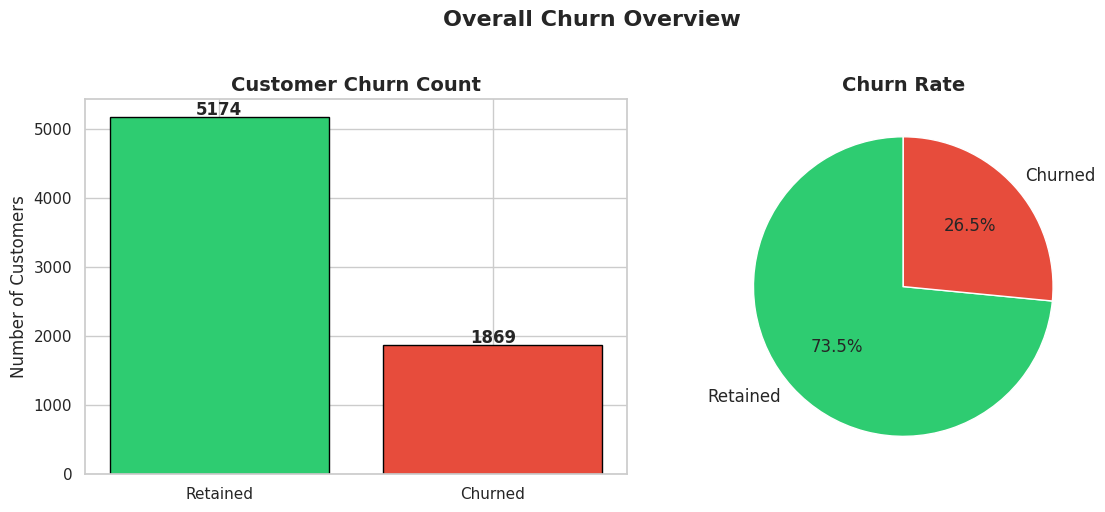

Chart saved


In [2]:

# SECTION 1 — Churn Distribution chart

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(['Retained', 'Churned'], churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Rate', fontsize=14, fontweight='bold')

plt.suptitle('Overall Churn Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save it
plt.savefig('/content/drive/MyDrive/projects /customer churn analysis/visuals/01_churn_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

## Finding 1 — Churn Overview

- **26.5% churn rate** → 1 in 4 customers is leaving
- Telecom industry average is ~15–20% → this company is underperforming
- 1,869 customers churned × $64 avg monthly charge =
    $119,616 in monthly revenue lost
- This confirms churn is a serious business problem worth solving

-->  Next: Who exactly is churning? Let's break it down by demographics

## Section 2 — Demographics vs Churn
**Business Question:** Do gender, age, partner status or dependents
influence churn?

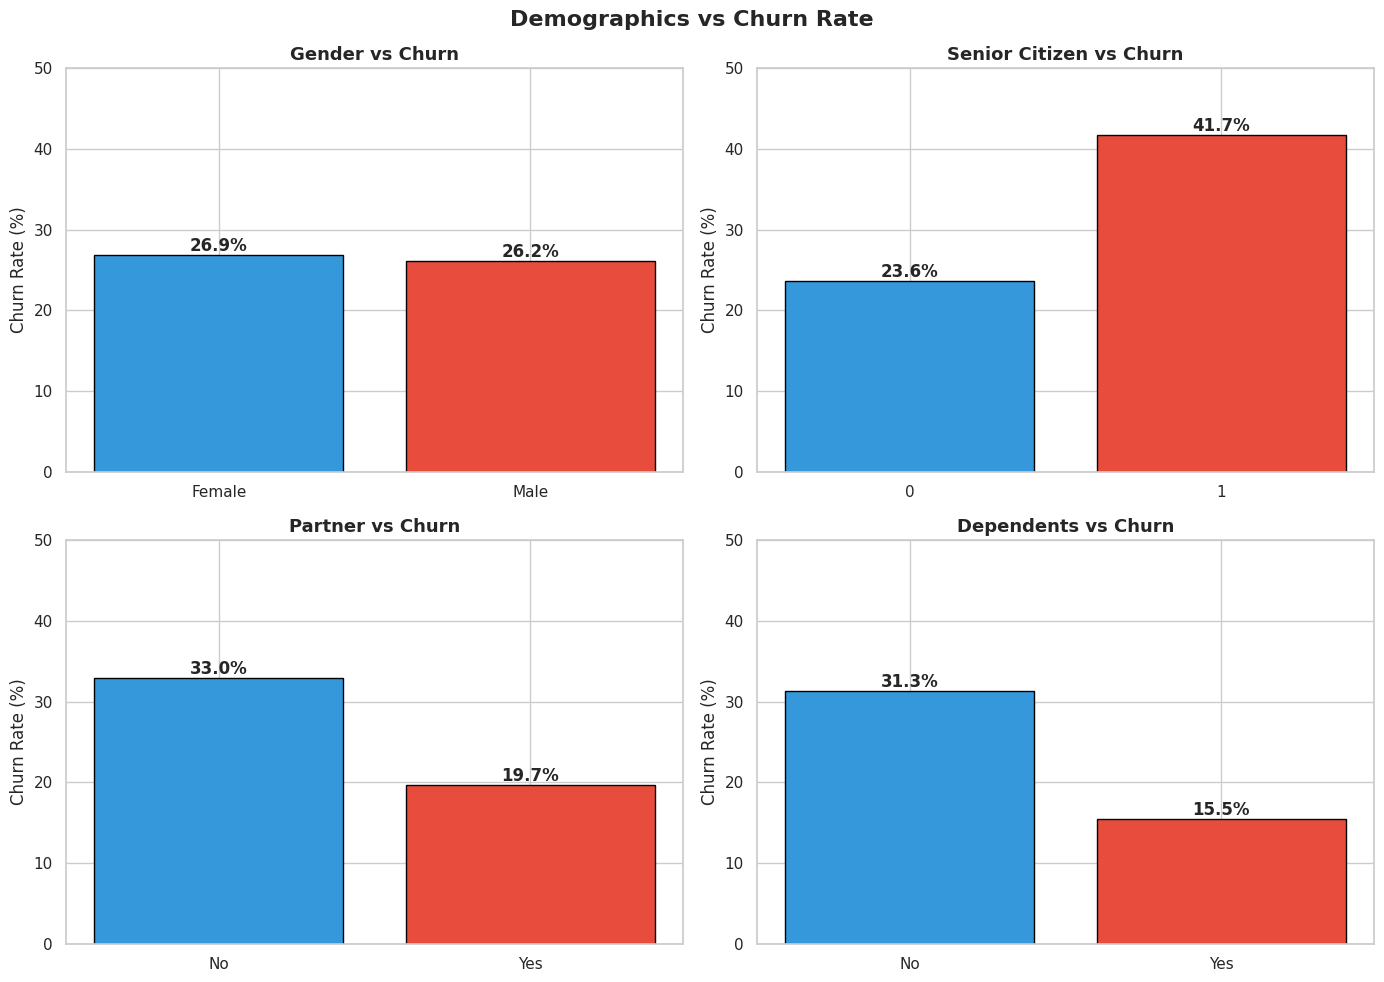

 Chart saved


In [3]:
# SECTION 2 — Demographics vs Churn
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

demographic_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
titles = ['Gender vs Churn', 'Senior Citizen vs Churn',
          'Partner vs Churn', 'Dependents vs Churn']

for i, (col, title) in enumerate(zip(demographic_cols, titles)):
    ax = axes[i//2][i%2]

    # Calculate churn rate per category
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'Churn Rate']

    bars = ax.bar(churn_rate[col].astype(str),
                  churn_rate['Churn Rate'],
                  color=['#3498db', '#e74c3c'],
                  edgecolor='black')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 50)

    # Add percentage labels on bars
    for bar, val in zip(bars, churn_rate['Churn Rate']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Demographics vs Churn Rate', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/projects /customer churn analysis/visuals/02_demographics_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved")

## Finding 2 — Demographics vs Churn

| Segment | Churn Rate | Risk Level |
|---|---|---|
| Senior Citizens | 41.7% | 🔴 High |
| No Partner | 33.0% | 🔴 High |
| No Dependents | 31.3% | 🟡 Medium |
| Non-Seniors | 23.6% | 🟢 Low |
| Has Dependents | 15.5% | 🟢 Low |

- Gender has NO meaningful impact on churn (0.7% difference)
- Senior citizens churn at nearly 2x the rate of non-seniors
- Family-oriented customers (partner + dependents) are most loyal
- **Retention strategy:** Target senior and single customers with
  special loyalty plans

--> Next: How do contracts and services affect churn?

## Section 3 — Contract & Services vs Churn
**Business Question:** Do contract type, payment method and
internet service affect churn?

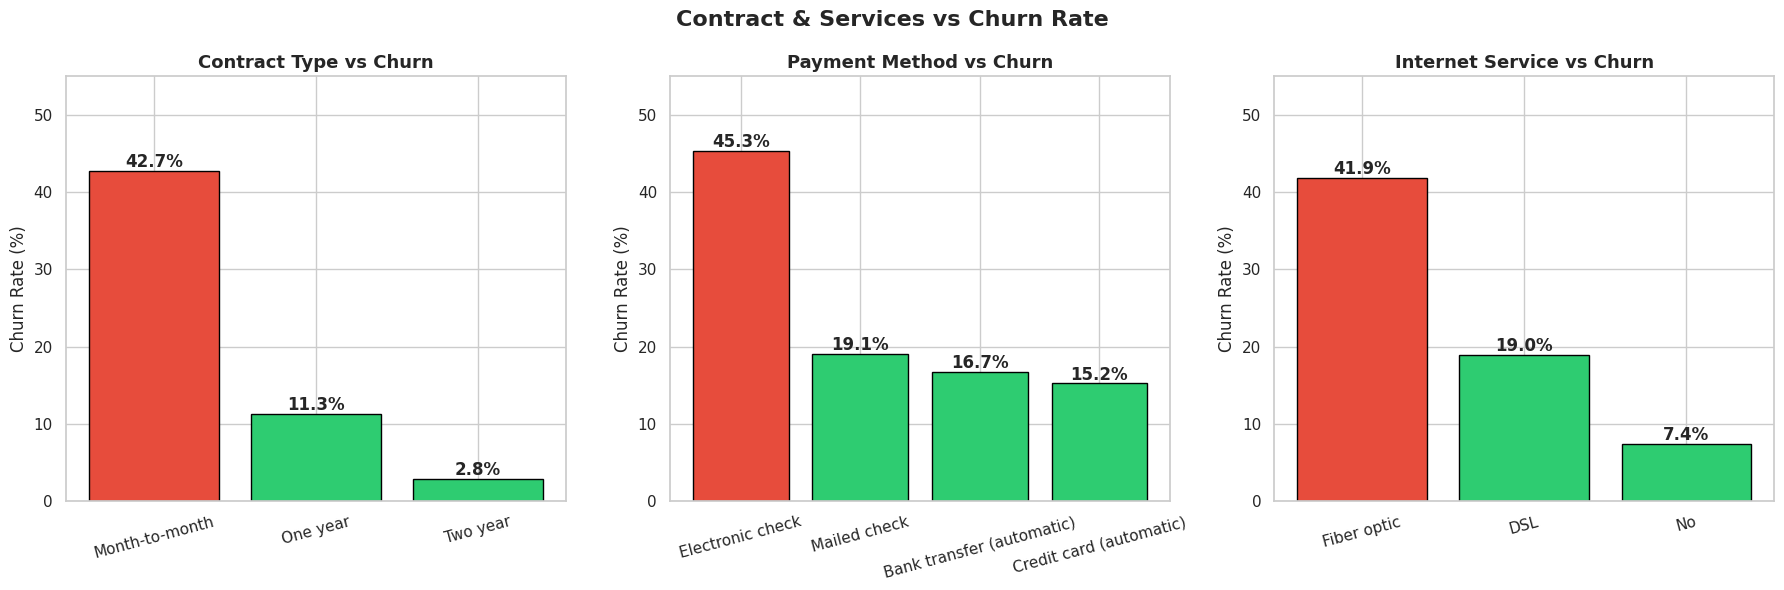

✅ Chart saved


In [5]:
# ============================================================
# SECTION 3 — Contract & Services vs Churn
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

service_cols = ['Contract', 'PaymentMethod', 'InternetService']
titles = ['Contract Type vs Churn',
          'Payment Method vs Churn',
          'Internet Service vs Churn']

for i, (col, title) in enumerate(zip(service_cols, titles)):
    ax = axes[i]

    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'Churn Rate']
    churn_rate = churn_rate.sort_values('Churn Rate', ascending=False)

    colors = ['#e74c3c' if v > 30 else '#f39c12' if v > 20
              else '#2ecc71' for v in churn_rate['Churn Rate']]

    bars = ax.bar(churn_rate[col], churn_rate['Churn Rate'],
                  color=colors, edgecolor='black')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 55)
    ax.tick_params(axis='x', rotation=15)

    for bar, val in zip(bars, churn_rate['Churn Rate']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Contract & Services vs Churn Rate',
             fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/projects /customer churn analysis/visuals/03_contract_services_churn.png',  dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

## Finding 3 — Contract & Services vs Churn

| Factor | Highest Risk | Churn Rate |
|---|---|---|
| Contract | Month-to-month | 42.7% 🔴 |
| Payment | Electronic check | 45.3% 🔴 |
| Internet | Fiber optic | 41.9% 🔴 |

**Key Insights:**
- Month-to-month customers churn 15x more than two-year customers
- Electronic check = zero friction to leave → highest churn payment method
- Fiber optic churn suggests a service quality/value problem
- Automatic payment customers (bank transfer + credit card) are most loyal

**Business Recommendations:**
- Incentivize customers to upgrade to annual/two-year contracts
- Offer discounts for switching to automatic payments
- Investigate fiber optic service quality complaints

--> Next: How do charges and tenure affect churn?

## Section 4 — Charges & Tenure vs Churn
**Business Question:** Do how long a customer stays and how much
they pay influence their likelihood to churn?

In [6]:
# Fix TotalCharges to numeric first (we spotted this in Phase 1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

/tmp/ipykernel_3091/270088167.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([retained_monthly := df[df['Churn']=='No']['MonthlyCharges'],
/tmp/ipykernel_3091/270088167.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('tenure_group')['Churn'].apply(


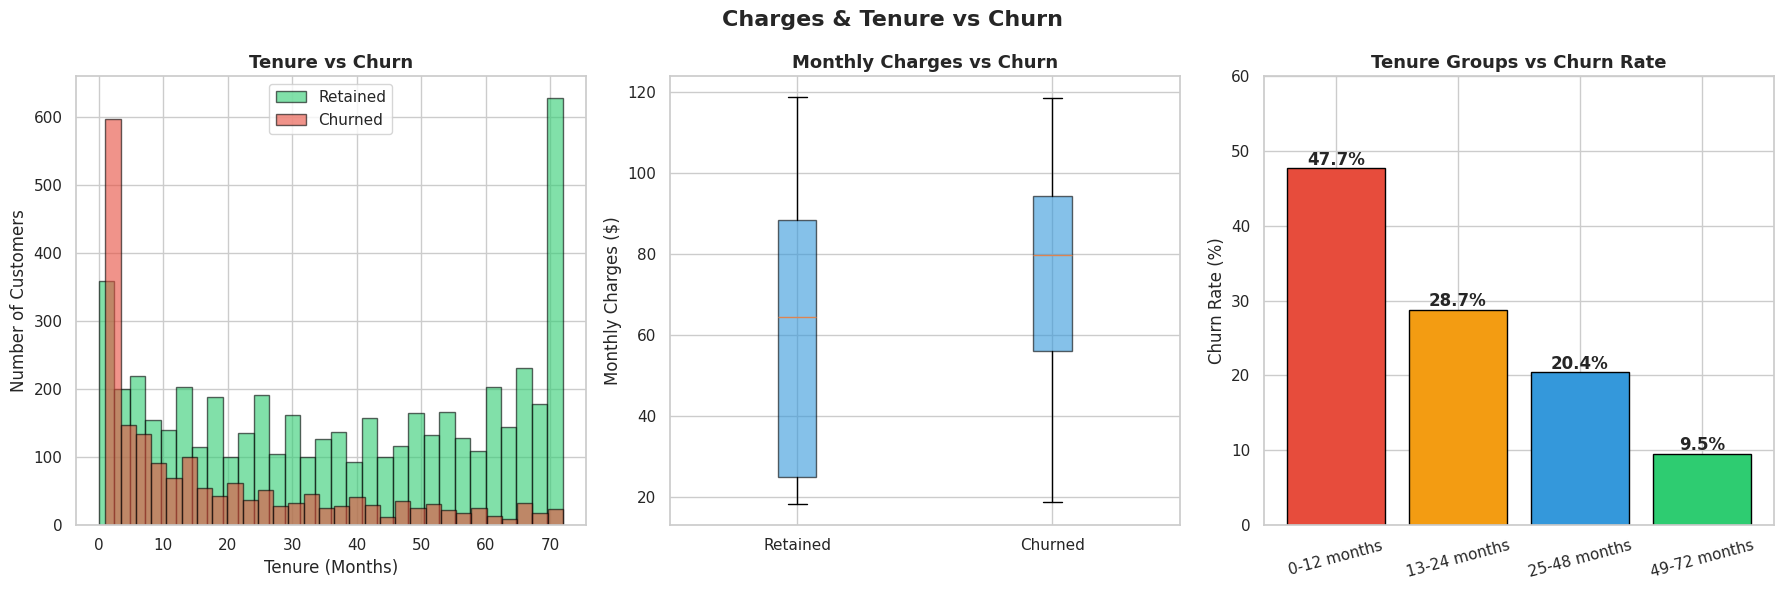

✅ Chart saved


In [7]:
# ============================================================
# SECTION 4 — Charges & Tenure vs Churn
# ============================================================


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Chart 1: Tenure Distribution by Churn ---
churned = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']

axes[0].hist(retained, bins=30, alpha=0.6, color='#2ecc71',
             label='Retained', edgecolor='black')
axes[0].hist(churned, bins=30, alpha=0.6, color='#e74c3c',
             label='Churned', edgecolor='black')
axes[0].set_title('Tenure vs Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# --- Chart 2: Monthly Charges by Churn ---
axes[1].boxplot([retained_monthly := df[df['Churn']=='No']['MonthlyCharges'],
                 churned_monthly := df[df['Churn']=='Yes']['MonthlyCharges']],
                labels=['Retained', 'Churned'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1].set_title('Monthly Charges vs Churn', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Monthly Charges ($)')

# --- Chart 3: Tenure Groups vs Churn Rate ---
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-12 months', '13-24 months',
                                     '25-48 months', '49-72 months'])

tenure_churn = df.groupby('tenure_group')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
tenure_churn.columns = ['tenure_group', 'Churn Rate']

colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = axes[2].bar(tenure_churn['tenure_group'],
                   tenure_churn['Churn Rate'],
                   color=colors, edgecolor='black')
axes[2].set_title('Tenure Groups vs Churn Rate', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_ylim(0, 60)
axes[2].tick_params(axis='x', rotation=15)

for bar, val in zip(bars, tenure_churn['Churn Rate']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Charges & Tenure vs Churn', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/projects /customer churn analysis/visuals/04_charges_tenure_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

##  Finding 4 — Charges & Tenure vs Churn

| Tenure Group | Churn Rate | Risk |
|---|---|---|
| 0–12 months | 47.7% | 🔴 Critical |
| 13–24 months | 28.7% | 🟡 High |
| 25–48 months | 20.4% | 🔵 Medium |
| 49–72 months | 9.5% | 🟢 Low |

**Key Insights:**
- First 12 months = danger zone, nearly 1 in 2 new customers churns
- Churned customers pay higher monthly charges → value-expectation mismatch
- Loyalty increases sharply after 2 years
- Longer tenure = strongest predictor of retention

**Business Recommendations:**
- Launch a 90-day and 6-month onboarding program for new customers
- Offer loyalty rewards at the 12-month milestone to push past danger zone
- Review pricing for high-charge customers to justify value

--> Next: Correlation heatmap to see all relationships at once

## Section 5 — Correlation Heatmap
**Business Question:** Which numerical variables are most strongly
related to each other and to churn?

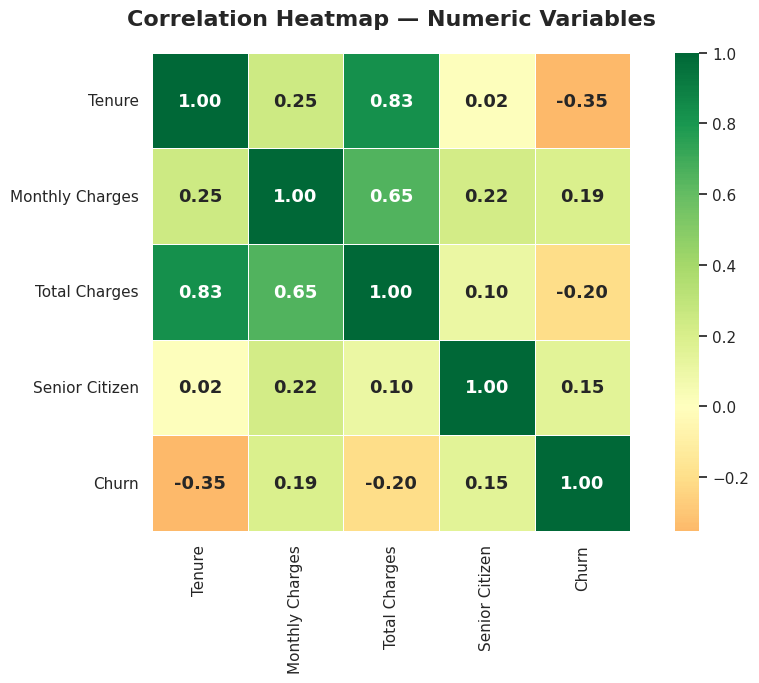

✅ Chart saved


In [8]:
# ============================================================
# SECTION 5 — Correlation Heatmap
# ============================================================

# Create a numeric version of churn for correlation
df['Churn_numeric'] = (df['Churn'] == 'Yes').astype(int)

# Select only numeric columns
numeric_cols = df[['tenure', 'MonthlyCharges',
                   'TotalCharges', 'SeniorCitizen',
                   'Churn_numeric']]

# Rename for cleaner display
numeric_cols.columns = ['Tenure', 'Monthly Charges',
                        'Total Charges', 'Senior Citizen', 'Churn']

# Calculate correlation
corr_matrix = numeric_cols.corr()

# Plot
plt.figure(figsize=(10, 7))

sns.heatmap(corr_matrix,
            annot=True,           # Show numbers inside
            fmt='.2f',            # 2 decimal places
            cmap='RdYlGn',        # Red = negative, Green = positive
            center=0,             # Center color at 0
            square=True,          # Square cells
            linewidths=0.5,       # Grid lines
            annot_kws={'size': 13, 'weight': 'bold'})

plt.title('Correlation Heatmap — Numeric Variables',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/projects /customer churn analysis/visuals/05_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")


##  Finding 5 — Correlation Heatmap

**Churn correlations (numeric variables only):**
- Tenure: -0.35 → strongest numeric predictor, longer customers churn less
- Monthly Charges: +0.19 → higher bills = slightly higher churn risk
- Total Charges: -0.20 → higher lifetime spend = slightly more loyal
- Senior Citizen: +0.15 → weak but consistent with demographics finding

**Key Observation:**
Numeric correlations with churn are all below 0.4 — meaning numeric
variables alone cannot explain churn. The strongest churn drivers are
categorical (contract type, payment method, internet service) found in
Section 3. This confirms we need both EDA approaches together.

**Multicollinearity flag:**
Tenure & Total Charges = 0.83 → very high correlation between them.
Will need to handle this carefully during feature engineering in Phase 3.

--> Phase 2 EDA Complete. Moving to Phase 3 — Data Cleaning & Feature Engineering